In [1]:
from typing import List, Dict

In [2]:
import tensorflow as tf

# List available hardware
devices: List = tf.config.list_physical_devices()
print(f"Devices found: {devices}")

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
gpu_devices: List = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print(f"GPU devices found: {gpu_devices}")

    for each_gpu_device in gpu_devices:
        tf.config.experimental.set_memory_growth(each_gpu_device, True)

else:
    print("Running on Local CPU")

GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Remarks: How to Fetch the Dataset

We will use `Garbage Classification Dataset` from [Kaggle](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification) for this project

### Dataset Description

Messr chchangcs curated a dataset of 2527 image datasets of garbages. The dataset contains 6 garbage categories, each having various count of images. These categories include:
* cardboard
* glass
* metal
* paper
* plastic
* trash

Other than images, the dataset also contains five TXT files, namely:
* one-indexed-files-notrash_train.txt
* one-indexed-files-notrash_val.txt
* one-indexed-files-notrash_test.txt
* one-indexed-files.txt
* zero-indexed-files.txt


### Authentication

Authentication is needed to download this dataset from Kaggle

First, you will need a Kaggle account. You can sign up [here](https://www.kaggle.com/account/login)

After login, you can download your Kaggle API token at [here](https://www.kaggle.com/settings) by clicking on the "Generate new Token" button under the "API" section.

You have several options to authenticate:

Option 1: kagglehub.login()

```Python
import kagglehub

kagglehub.login()
```
This will prompt you to enter your Kaggle API token.

Option 2: Environment Variable

```Bash
export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx # Coped from the settings UI
```

Option 3: API Token File

Store your Kaggle API token obtained from your [setting page](https://www.kaggle.com/settings) to a file located in `~/.kaggle/access_token`

Option 4: Google Colab Secret

If you are running this notebook from Google Cloud, then you can store your API token in a Colab secret named `KAGGLE_API_TOKEN`.

Instructions on adding secrets in Colab can be found [here](https://www.googlecloudcommunity.com/gc/Cloud-Hub/How-do-I-add-secrets-in-Google-Colab-Enterprise/m-p/784866)

Option 5: Legacy API credentials file

From your [Kaggle Account Setting Page](https://www.kaggle.com/settings), under the "Legacy API Credentials", click on the "Create Legeacy API Key" button to generate a `kaggle.json` file and store it at `~/.kaggle/kaggle.json`

In [4]:
# Authenticate Kaggle

import os
from pathlib import Path


import kagglehub

is_authenticated: bool = False

api_key_path: Path = Path("~/.kaggle/kaggle.json").expanduser()
is_api_key_exists: bool = True if api_key_path.exists() else False

api_token_path: Path = Path("~/.kaggle/access_token").expanduser()
is_api_token_exists: bool = True if api_token_path.exists() else False

## Check if running in Colab
def is_colab() -> bool:
    """
    Small utility function to check if this notebook is running on Colab
    :return: Boolean indication if this script is running on Colab
    :rtype bool
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False

is_colab_secret_exists: bool = False
if is_colab():
    from google.colab import userdata

    try:
        is_colab_secret_exists = True if userdata.get("KAGGLE_API_TOKEN") else False
    except userdata.SecretNotFoundError:
        is_colab_secret_exists = False

is_token_env_exists: bool = True if os.getenv("KAGGLE_API_TOKEN") else False

is_token_via_login: bool = False
if all([
    not is_api_key_exists
    , not is_api_token_exists
    , not is_colab_secret_exists
    , not is_token_env_exists
]):
    # if everything above fails, then login interactively
    # this will ask you to input the Kaggle API Token from a UI
    kagglehub.login()
    is_token_via_login = True


if any([
    is_api_key_exists
    , is_api_token_exists
    , is_token_env_exists
    , is_colab_secret_exists
    , is_token_via_login
]):
    is_authenticated = True
    print("Kagglehub has been authenticated")

else:
    raise Exception(" 🛑 Kagglehub fails to authenticate")

Kagglehub has been authenticated


## Remarks: Download the Dataset

In this section, we will download the dataset from Kaggle.

We want to detect if any `.jpg` files already present under `dataset/` folder.

If not, then we: (1) would download the dataset from Kaggle, (2) copy the downloaded data from Kaggle's `cache/` folder into the project's `dataset/` folder. If `.jpg` files already present in the `dataset/` folder, then we will simply load the data from the `dataset/` folder.

This way, we can avoid downloading the dataset every time we run this notebook.

In [5]:
# Download Data Smartly
# If the data is not yet downloaded, we will first download the data from Kaggle to `dataset` folder, and then load them to pandas
# Else, we will load the data from the `dataset` folder directly to pandas

from pathlib import Path
import shutil

import kagglehub

kaggle_dataset_handler_str: str = "asdasdasasdas/garbage-classification"

project_root: Path = Path.cwd().expanduser()
dataset_folder: Path = project_root / "dataset"

dataset_folder.mkdir(parents=True, exist_ok=True)

available_files = sorted(
    each_found_file.name for each_found_file in dataset_folder.glob("**/*")
    if each_found_file.suffix in {".jpg", ".txt"}
)

if available_files:
    print("Dataset already exists locally. Using files from `dataset` folder.")
    print(f"Count of available files: {len(available_files)}")
else:
    downloaded_path_str: str = kagglehub.dataset_download(
        handle=kaggle_dataset_handler_str
    )
    downloaded_path: Path = Path(downloaded_path_str)
    # dataset_gambar_path: Path = downloaded_path / "Garbage classification"

    shutil.copytree(
        src = downloaded_path
        , dst = dataset_folder
        , dirs_exist_ok = True
    )

    available_files = sorted(
        each_found_file.name for each_found_file in dataset_folder.glob("**/*")
        if each_found_file.suffix in {".jpg", ".txt"}
    )

    print(f"Count of available files: {len(available_files)}")

Dataset already exists locally. Using files from `dataset` folder.
Count of available files: 2532


## Remark: Create Image Labels

We will create labels for each image by using the parent folder name.

We will convert each label name string into an integer, so that it will be easuer for us to do the data pre-processing later on

In [6]:
## Get the category names

from typing import List, Dict
from pprint import pprint

garbage_cls_folder: Path = dataset_folder / "Garbage classification" / "Garbage classification"

garbage_cls_names: List[str] = [each_folder.name for each_folder in garbage_cls_folder.iterdir()]

categ_dict: Dict[str, int] = {}
for each_idx, each_cls in enumerate(sorted(garbage_cls_names)):
    categ_dict[each_cls] = each_idx

pprint(categ_dict, indent=4)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [7]:
## label images
from typing import Union

ClassLabel = List[Dict[str, Union[str, int]]]

def label_images(
        image_paths: List[Path],
        categ_dict: Dict[str, int],
) -> ClassLabel:

    class_labels: ClassLabel = []

    for each_img_path in image_paths:
        label_name: str = each_img_path.parent.name
        categ_int: int = categ_dict[label_name]

        img_label: Dict = {
            "image_path": str(each_img_path)
            , "categ_int": categ_int
        }

        class_labels.append(img_label)

    return class_labels

In [8]:
garbage_img_paths: List[Path] = [each_path for each_path in garbage_cls_folder.glob("**/*.jpg")]

labeled_garbages: ClassLabel = label_images(
    image_paths=garbage_img_paths
    , categ_dict=categ_dict
)

pprint(labeled_garbages, indent=4)

[   {   'categ_int': 3,
        'image_path': '/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/dataset/Garbage '
                      'classification/Garbage '
                      'classification/paper/paper283.jpg'},
    {   'categ_int': 3,
        'image_path': '/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/dataset/Garbage '
                      'classification/Garbage '
                      'classification/paper/paper297.jpg'},
    {   'categ_int': 3,
        'image_path': '/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/dataset/Garbage '
                      'classification/Garbage '
                      'classification/paper/paper526.jpg'},
    {   'categ_int': 3,
        'image_path': '/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/datase

## Remark: EDA

Before splitting the images into training, validation, and test sets, it helps to first understand the dataset a bit better. In particular, we want to look at the label distribution and also check the distribution of image widths and heights.

This is important for two reasons:
* First, we want the label distribution to stay as consistent as possible across the training, validation, and test splits, so that each subset fairly represents the full dataset.
* Second, we want to confirm whether the image dimensions are consistent across all images, since this will matter later when we build and train the model.

In [9]:
## Visualize Distribution of Labels

from collections import Counter

from matplotlib import pyplot as plt

def viz_label_distribution(
       labeled_garbages: ClassLabel,
) -> Dict[int, int]:

    label_counter: Counter = Counter(
        each_dict["categ_int"]
        for each_dict in labeled_garbages
    )

    label_counts: Dict[int, int] = dict(sorted(label_counter.items()))

    color: Dict[str, str] = {
        "categories" : "#2E86AB"
    }

    fig, ax = plt.subplots(
        figsize=(10, 10),
    )

    ax.bar(
        x = label_counts.keys()
        , height = list(label_counts.values())
        , color = color["categories"]
    )

    ax.set_title("Garbage Classification")
    ax.set_xlabel("Garbage Categories")
    ax.set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

    return label_counts

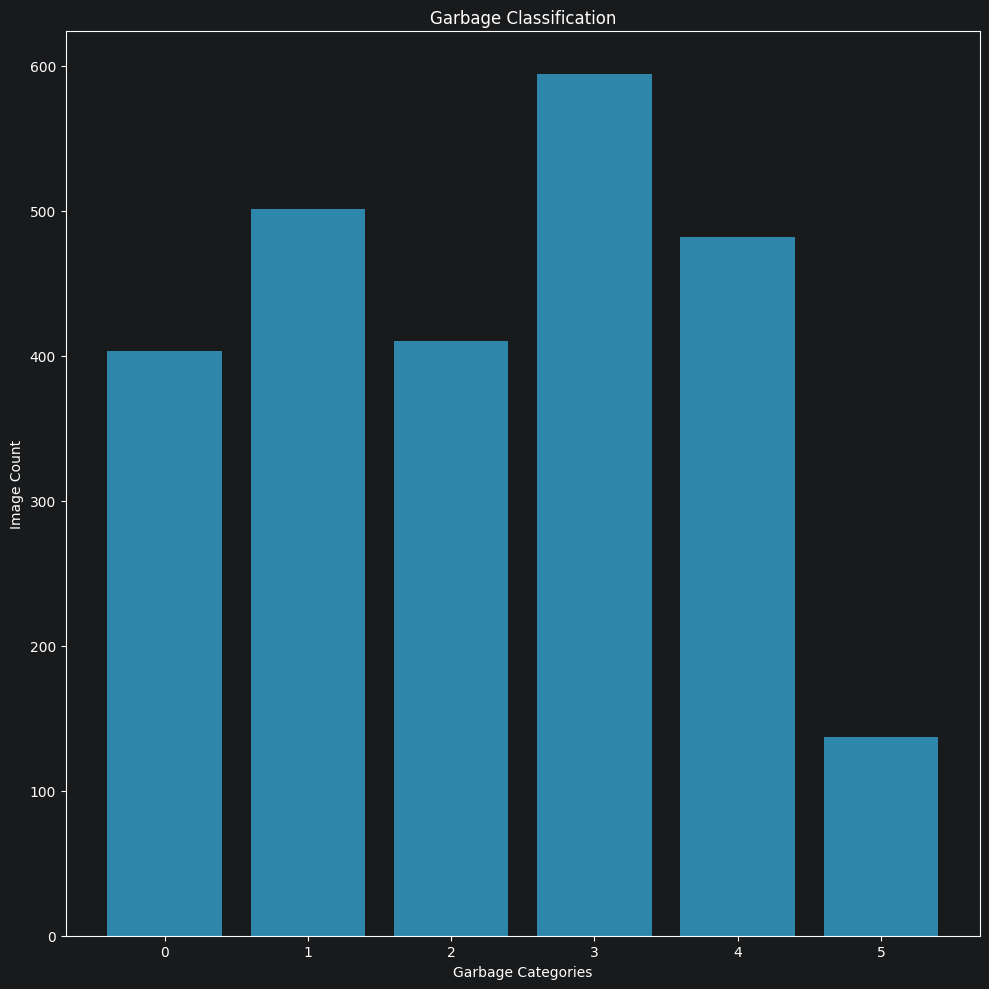

{0: 403, 1: 501, 2: 410, 3: 594, 4: 482, 5: 137}

In [10]:
viz_label_distribution(
    labeled_garbages = labeled_garbages
)

As noted, the class distribution is not equal.

Particularly, class `#5` has the smallest count of members amongst other classes.

Hence, for this reason, we will drop class `#5` from being modeled moving forward.

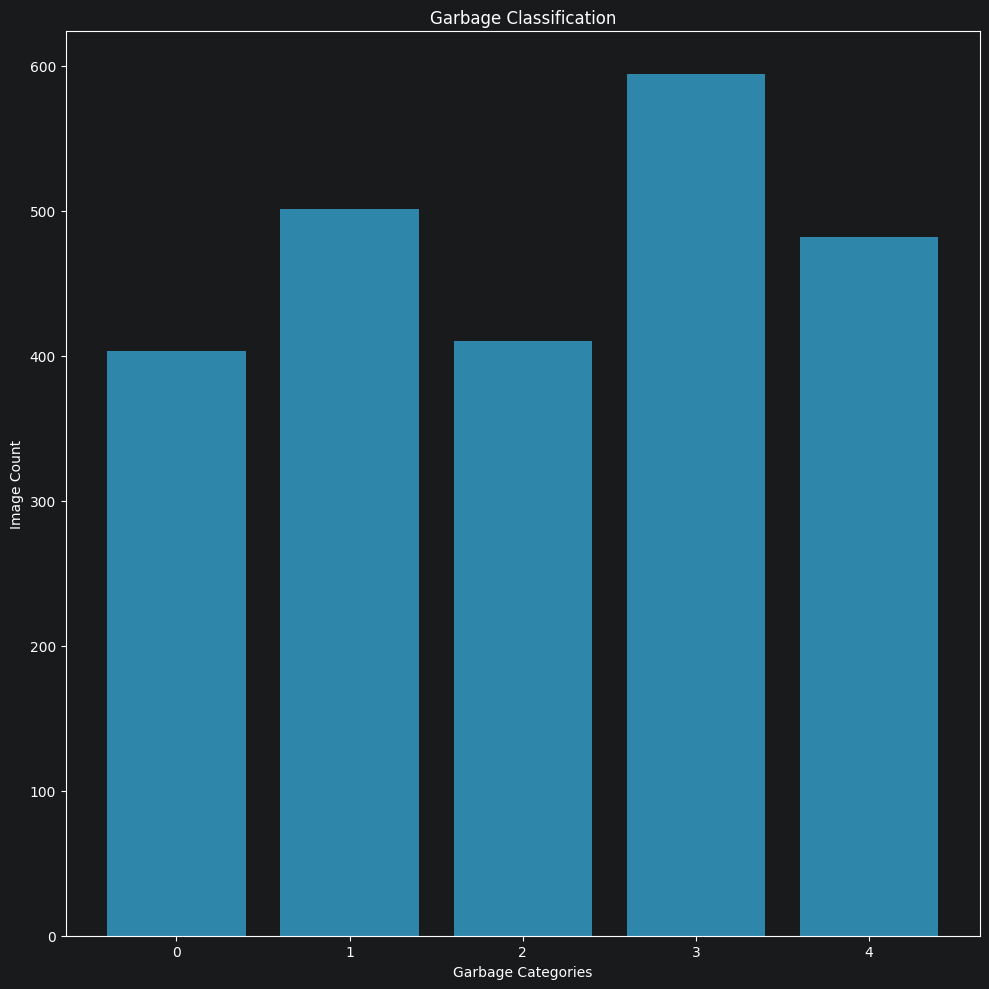

In [11]:
# removing images labeled with class `#5`

tmp_labeled_garbages: ClassLabel = [
    each_dict for each_dict in labeled_garbages if each_dict["categ_int"] != 5
]

viz_label_distribution(
    labeled_garbages = tmp_labeled_garbages
)

labeled_garbages = tmp_labeled_garbages.copy() # replace original labeled_garbages with one in whihch the label `#5` has been removed

In [12]:
## Visualize image size distribution

from collections import Counter
from PIL import Image
import numpy as np

def viz_image_size_distribution(
        labeled_garbages: ClassLabel,
) -> None:

    size_counter: Counter = Counter(
        sorted(
            Image.open(each_dict["image_path"]).size
            for each_dict in labeled_garbages
        )
    )

    size_count: Dict = dict(
                            sorted(size_counter.items())
                        )

    color: Dict[str, str] = {
        "categories" : "#2E86AB"
    }

    fig, ax = plt.subplots(
        figsize=(10, 10),
    )

    ax.bar(
        x = str(size_count.keys())
        , height = list(size_count.values())
        , color = color["categories"]
    )

    ax.set_title("Garbage Classification")
    ax.set_xlabel("Image Size")
    ax.set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

    pprint(size_count, indent=4)

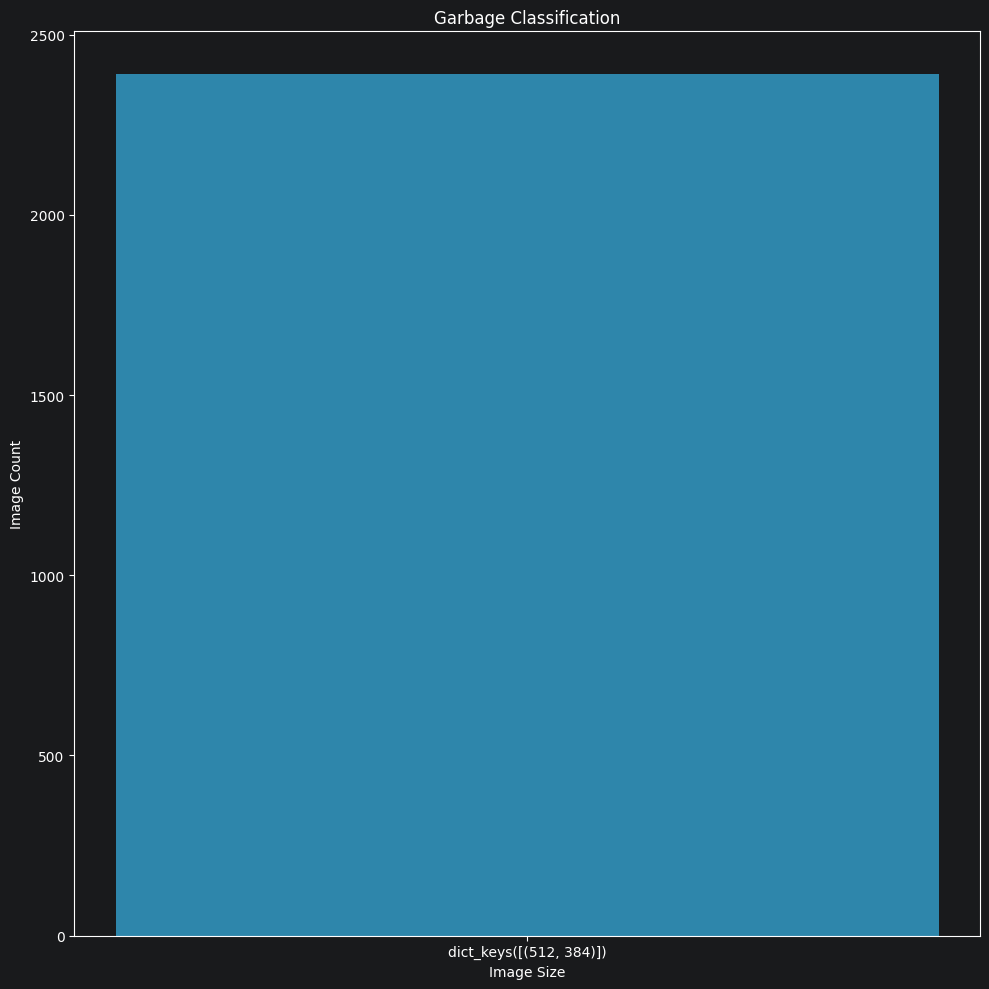

{(512, 384): 2390}


In [13]:
viz_image_size_distribution(
    labeled_garbages = labeled_garbages
)

We notice that all images have the same shape, namely: (512, 384).

This would simplify our data pre-processing downstream somewhat

## Remark: Data Pre-Processing - Resize Images

As a first preprocessing step, we will resize the images from their original shape of `(512, 384, 3)` to `(224, 224, 3)`.

As in the previous `Indonesian Food` session, we chose `(224, 224, 3)` because it makes comparison easier when using ViT alongside other pretrained models that were trained on the `ImageNet` dataset

In [14]:
## Define function to resize the smallest dimension to 224 pixel

from PIL import Image
import numpy as np

def resize_shortest(
        img: Image.Image
) -> np.ndarray:

    """Resize an image so its shortest side becomes 224 pixels.

    This function converts the input image to RGB mode, computes a scale
    factor from the shortest spatial dimension, and resizes the image while
    preserving its aspect ratio. The resized image is returned as a NumPy
    array with three RGB channels.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image to be resized.
        Default value: no default value.

    Returns
    -------
    np.ndarray
        Resized RGB image as a NumPy array with shape `(height, width, 3)`.
    """

    TARGET_SIZE: int = 224

    # Ensure the image is in RGB format
    rgb_image: Image.Image = img.convert("RGB")

    scale_factor: float = TARGET_SIZE / min(rgb_image.height, rgb_image.width)
    new_w: int = round(rgb_image.width * scale_factor)
    new_h: int = round(rgb_image.height * scale_factor)

    resized_image: Image.Image = rgb_image.resize(
        size = (new_w, new_h)
        , resample = Image.Resampling.LANCZOS
    )

    scaled_image_np: np.ndarray = np.array(resized_image)

    return scaled_image_np

In [15]:
# Define function to crop image from the center
def crop_from_center(
        img: np.ndarray
) -> np.ndarray:

    """Crop the center region of an image to 224 x 224 pixels.

    This function extracts a square crop from the center of a NumPy image
    array. It assumes the input image has already been resized so that both
    spatial dimensions are at least 224 pixels. The output preserves the
    original channel dimension and returns the centered crop as a NumPy
    array.

    Parameters
    ----------
    img : np.ndarray
        Input image as a NumPy array with shape `(height, width, channels)`.
        Default value: no default value.

    Returns
    -------
    np.ndarray
        Center-cropped image as a NumPy array with shape `(224, 224, channels)`.
    """

    TARGET_SIZE: int = 224

    image_h: int = img.shape[0]
    image_w: int = img.shape[1]

    if image_h < TARGET_SIZE or image_w < TARGET_SIZE:
        raise ValueError("Input image must be at least 224x224 before center cropping.")

    left_pt: int = (image_w - TARGET_SIZE) // 2
    right_pt: int = left_pt + TARGET_SIZE

    top_pt: int = (image_h - TARGET_SIZE) // 2
    bottom_pt: int = top_pt + TARGET_SIZE

    cropped_image_np: np.ndarray = img[top_pt:bottom_pt, left_pt:right_pt, :]

    return cropped_image_np

In [16]:
def resize_and_crop_image(
        img: Image.Image
)-> np.ndarray:

    """Resize and Crop Image to (224, 224, 3) size

    This function takes an image as input and perform the following steps:
    1. Resize the image to (height, 224) or (224, height) using the resize_shortest function
    2. Crop the resized image to (224, 224, 3) using the crop_from_center function

    Parameters
    ---------
    :param img: PIL.Image.Image
        PIL Image object  to be resized and cropped
        Default value: no default value.

    Returns
    :return: np.ndarray
        Resized and Cropped Image as a NumPy array with shape (224, 224, 3)
    """

    # first, we resize the image
    resized_img: np.ndarray = resize_shortest(img = img)

    # Seccond, we crop the image from the center
    cropped_img: np.ndarray = crop_from_center(img = resized_img)

    return cropped_img

Original Image Size: (512, 384)


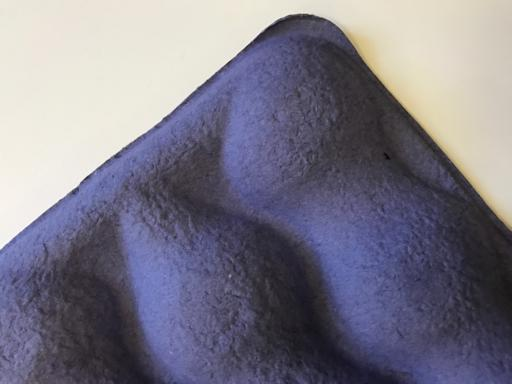

In [17]:
# Test the resize-and-crop utiliy function

test_image_dict: Dict[str, Union[str, Path]] = labeled_garbages[0]
test_image_path: Path = test_image_dict["image_path"]
test_image: Image.Image = Image.open(test_image_path)

print(f"Original Image Size: {test_image.size}")
display(test_image)

Resized and Cropped Image Size: (224, 224, 3)


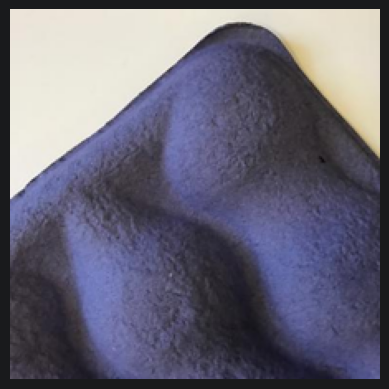

In [18]:
from matplotlib import pyplot as plt
import numpy as np

prc_img: np.ndarray = resize_and_crop_image(img = test_image)

print(f"Resized and Cropped Image Size: {prc_img.shape}")
plt.imshow(prc_img)
plt.axis("off")
plt.show()

## 🧠 Food For Thought

The notebook resizes all images to 224 x 224 to match the pretrained ViT input. What information might be lost from the original images during this resizing step, and how could that affect classification performance for small or fine-grained garbage objects?

After we're done preparing the utility function to resize_and_crop images, we then proceed to create another set of utility functions to preprocess the images for training and inference.

These functions will be used to load and preprocess images in a TensorFlow dataset pipeline.

In [19]:
from typing import Tuple, List, Dict, Union
from pathlib import Path

import numpy as np
import tensorflow as tf
from PIL import Image

In [20]:
def prepare_records(
        labeled_images: ClassLabel
) -> Tuple[List[str], List[int]]:

     image_paths: List[str] = [
         str(each_item["image_path"]) for each_item in labeled_images
     ]

     labels_int: List[int] = [
        each_item["categ_int"] for each_item in labeled_images
     ]

     return image_paths, labels_int

In [21]:
image_paths, categ_int = prepare_records(labeled_images = labeled_garbages)

print("Image Paths")
print(image_paths[:3])

print("Categorie Int")
print(categ_int[:3])

Image Paths
['/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/dataset/Garbage classification/Garbage classification/paper/paper283.jpg', '/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/dataset/Garbage classification/Garbage classification/paper/paper297.jpg', '/Users/iputumahendrawijaya/BinusProjects/20260324_garbage_classification/vit_202603_garbage_classification/dataset/Garbage classification/Garbage classification/paper/paper526.jpg']
Categorie Int
[3, 3, 3]


In [22]:
# Prepare train : validation : test data split

from sklearn.model_selection import train_test_split

train_paths, tmp_paths, train_ctg, tmp_ctg = train_test_split(
    image_paths
    , categ_int
    , test_size = 0.2
    , stratify = categ_int    # this parameter `stratify=categ_int` would ensure that the group will (mostly) retain the distribution of each categories in original dataset
)

val_paths, test_paths, val_ctg, test_ctg = train_test_split(
    tmp_paths
    , tmp_ctg
    , test_size = 0.5
    , stratify = tmp_ctg
)

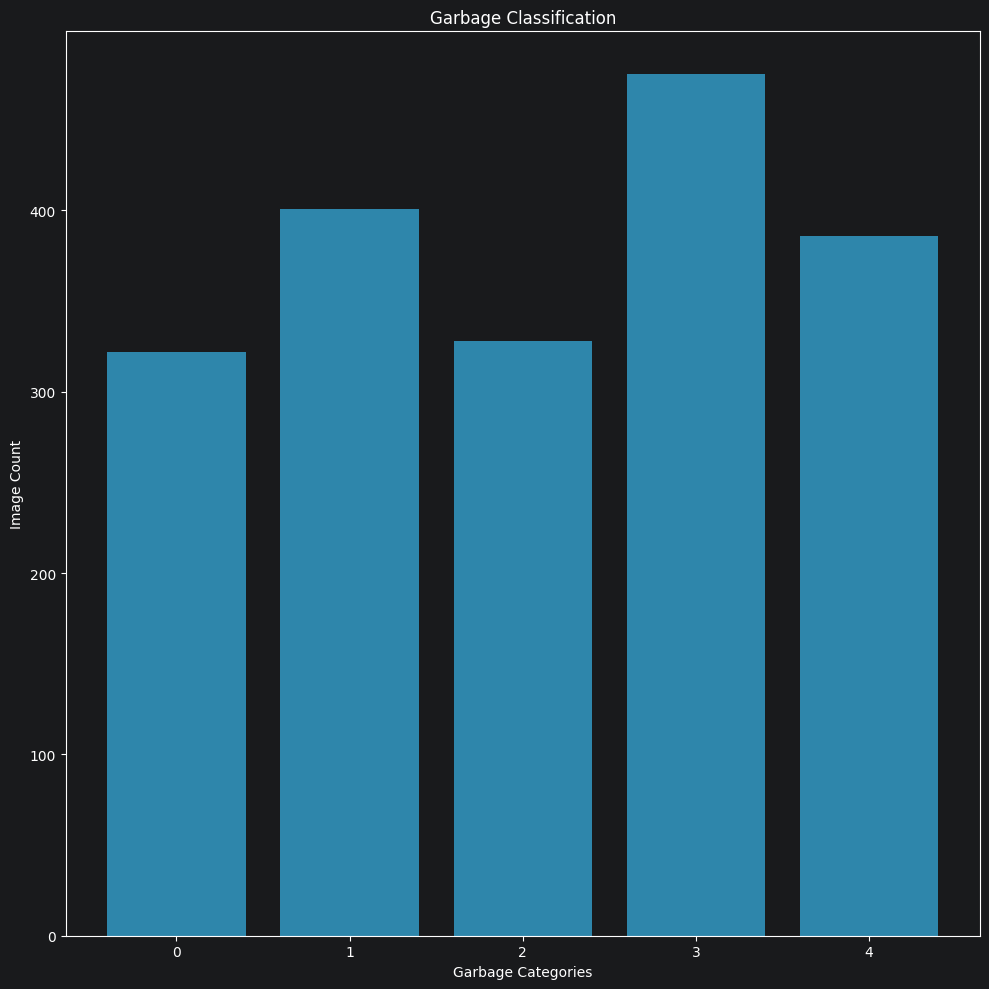

{0: 322, 1: 401, 2: 328, 3: 475, 4: 386}

In [23]:
# Check distribution of categories in train, validation, and test datasets

# Category Distribution in Train Dataset
train_labeled_garbage: ClassLabel = [
        {"image_path" : each_path, "categ_int" : each_ctg}
        for each_path, each_ctg in zip(train_paths, train_ctg)
    ]

viz_label_distribution(
    labeled_garbages = train_labeled_garbage
)

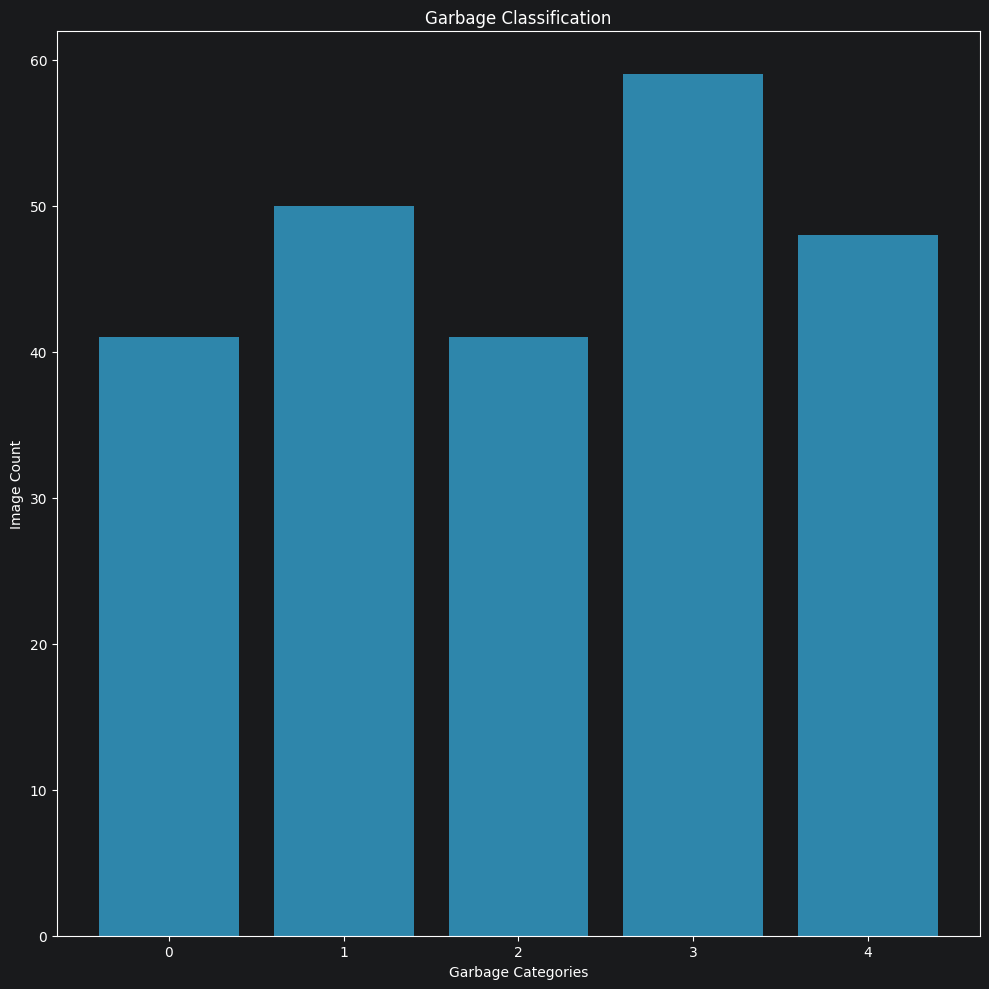

{0: 41, 1: 50, 2: 41, 3: 59, 4: 48}

In [24]:
# Category Distribution in Validation Dataset
val_labeled_garbage: ClassLabel = [
        {"image_path" : each_path, "categ_int" : each_ctg}
        for each_path, each_ctg in zip(val_paths, val_ctg)
    ]

viz_label_distribution(
    labeled_garbages = val_labeled_garbage
)

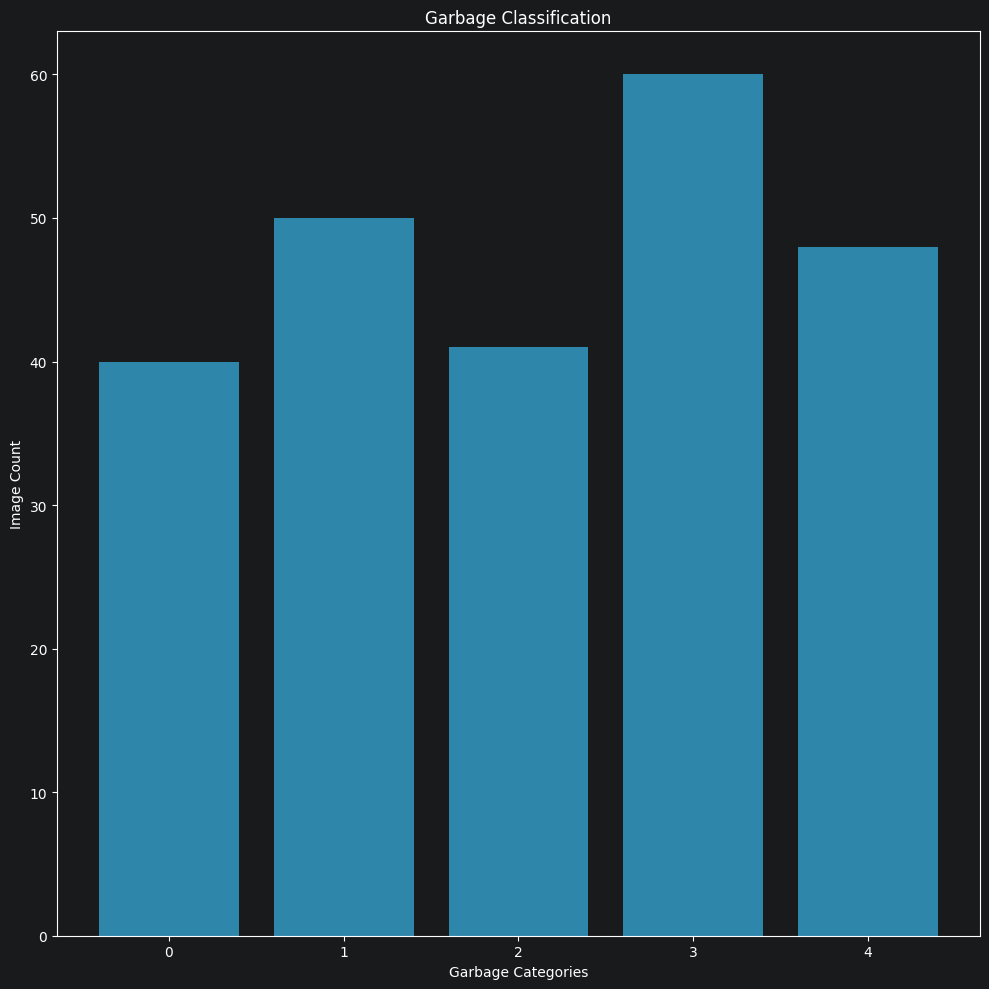

{0: 40, 1: 50, 2: 41, 3: 60, 4: 48}

In [25]:
# Category Distribution in Validation Dataset
test_labeled_garbage: ClassLabel = [
        {"image_path" : each_path, "categ_int" : each_ctg}
        for each_path, each_ctg in zip(test_paths, test_ctg)
    ]

viz_label_distribution(
    labeled_garbages = test_labeled_garbage
)

## Remark: Data Pre-Processing: Prepare Data Pipeline Utility Functions

Now that we have a function to resize the image to the expected shape, and now that we have split the dataset into train, validation, and test groups; subsequently, we want to proceed with defining a set of utility function to help us preparing dataset pipeline for training our model later

In [26]:
def load_and_preprocess_image_py(
        image_path_tensor: tf.Tensor
) -> tf.Tensor:

    image_path: str = image_path_tensor.numpy().decode("utf-8")

    with Image.open(image_path) as img:
        rc_image_np: np.ndarray = resize_and_crop_image(img = img)

    rc_image_np = rc_image_np.astype(np.float32) / 255.0

    rc_image_tf: tf.Tensor = tf.convert_to_tensor(rc_image_np)

    return rc_image_tf

In [27]:
def tf_preprocess_wrapper(
        image_path: tf.Tensor
        , label: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:

    image: tf.Tensor = tf.py_function(
        func = load_and_preprocess_image_py
        , inp = [image_path]
        , Tout = tf.float32
    )

    image.set_shape((224,224,3))

    return image, label

In [28]:
def build_dataset_from_labeled_images(
        labeled_images: ClassLabel
        , batch_size: int = 32
        , is_training: bool = False
) -> tf.data.Dataset:

    image_paths, labels = prepare_records(labeled_images = labeled_images)

    dst: tf.data.Dataset = tf.data.Dataset.from_tensor_slices(
        tensors = (image_paths, labels)
    )

    if is_training:
        dst = dst.shuffle(buffer_size = len(image_paths))

    dst = dst.map(tf_preprocess_wrapper, num_parallel_calls = tf.data.AUTOTUNE)
    dst = dst.batch(batch_size = batch_size)
    dst = dst.prefetch(buffer_size = tf.data.AUTOTUNE)

    return dst

In [29]:
import tensorflow as tf

BATCH_SIZE: int = 32
EPOCHS: int = 30

train_ds: tf.data.Dataset = build_dataset_from_labeled_images(
    labeled_images = train_labeled_garbage
    , batch_size = BATCH_SIZE
    , is_training = True
)

val_ds: tf.data.Dataset = build_dataset_from_labeled_images(
    labeled_images = val_labeled_garbage
    , batch_size = BATCH_SIZE
    , is_training = False
)

test_ds: tf.data.Dataset = build_dataset_from_labeled_images(
    labeled_images = test_labeled_garbage
    , batch_size = BATCH_SIZE
    , is_training = False
)

2026-04-04 11:37:25.146875: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-04 11:37:25.146898: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-04 11:37:25.146905: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-04 11:37:25.146921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-04 11:37:25.146931: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [30]:
## Login to HuggingFace
## To Login, put your HF_token into `cred/hf_token.json`

import huggingface_hub as hf
import json

hf_token_path: Path = project_root / "cred" / "hf_token.json"

with open(hf_token_path, mode="r") as tkp:
    hf_token: Dict = json.load(tkp)

hf.login(token = hf_token["value"])

In [31]:
from transformers import ViTImageProcessor
import tensorflow as tf

PRETRAINED_MODEL: str = "google/vit-base-patch16-224"

vit_hf_processor: ViTImageProcessor = ViTImageProcessor.from_pretrained(PRETRAINED_MODEL)

In [32]:
from typing import Tuple, Dict

IMAGE_MEAN: tf.Tensor = tf.constant(
    vit_hf_processor.image_mean
    , dtype = tf.float32
)

IMAGE_STD: tf.Tensor = tf.constant(
    vit_hf_processor.image_std
    , dtype = tf.float32
)

def to_vit_inputs(
        images: tf.Tensor
        , labels: tf.Tensor
) -> Tuple[Dict[str, tf.Tensor], tf.Tensor]:
    """
    Convert standard image batch into HuggingFace ViT input format.

    Args:
        images: Tensor of shape (B, H, W, C), dtype=tf.float32, range [0, 1]
        labels: Tensor of shape (B,), dtype=tf.int32 or tf.int64

    Returns:
        inputs: Dict with key "pixel_values" → (B, C, H, W)
        labels: unchanged
    """

    # ------------------------------------------------------------------
    # Type enforcement
    # ------------------------------------------------------------------
    images = tf.cast(images, dtype=tf.float32)

    # ------------------------------------------------------------------
    # Shape validation (useful for debugging)
    # ------------------------------------------------------------------
    tf.debugging.assert_rank(images, 4, message="Images must be rank-4 tensor")
    tf.debugging.assert_equal(
        tf.shape(images)[-1],
        3,
        message="Images must have 3 channels (RGB)"
    )

    # ------------------------------------------------------------------
    # Normalization (match ViT pretraining)
    # ------------------------------------------------------------------
    normalized_images: tf.Tensor = (images - IMAGE_MEAN) / IMAGE_STD

    # ------------------------------------------------------------------
    # Convert NHWC → NCHW (required by HuggingFace ViT)
    # ------------------------------------------------------------------
    pixel_values: tf.Tensor = tf.transpose(
        normalized_images,
        perm=[0, 3, 1, 2]
    )

    # ------------------------------------------------------------------
    # Return in HuggingFace expected format
    # ------------------------------------------------------------------
    inputs: Dict[str, tf.Tensor] = {
        "pixel_values": pixel_values
    }

    return inputs, labels

In [33]:
# ------------------------------------------------------------------
# Apply to Dataset Pipelines
# ------------------------------------------------------------------

train_vit_ds: tf.data.Dataset = train_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_vit_ds: tf.data.Dataset = val_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_vit_ds: tf.data.Dataset = test_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [34]:
import tensorflow as tf

try:
    from transformers import TFViTModel
except ValueError as err:
    raise RuntimeError(
        "This notebook uses the TensorFlow ViT implementation from HuggingFace. In this environment, Transformers is running with Keras 3, so you also need the compatibility package `tf-keras`. Install it in the same kernel environment, restart the kernel, then rerun from the ViT section onward."
    ) from err


## Remark: Prepare ViT Model

In this section, we will start to build ViT Model for image classification.

We will not build a ViT model from scratch for this task. Instead, we will take advantage Google's ViT model in `Hugging Face`, namely : `google/vit-base-patch16-224`

### Fine-Tune HuggingFace ViT

At this point, we are ready to fine-tune the pretrained HuggingFace ViT model for our garbage classification task.

We will do this in two stages:
1. train the new classification head while freezing the pretrained ViT backbone
2. unfreeze the ViT backbone and continue fine-tuning using a smaller learning rate

Because the dataset is not perfectly balanced, we will also compute `class_weight` from the training split and pass it into `model.fit(...)`.


In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

active_label_ids = sorted(set(train_ctg))

# Assert (check) if the Label Integer (idx) is continuous
# If the idx is not continuous, then `assert` will throw `AssertionError`
assert active_label_ids == list(range(len(active_label_ids))), (
    "Labels must be contiguous integers starting from 0 before fine-tuning ViT."
)

active_label_names = [
    each_name
    for each_name, each_idx in sorted(categ_dict.items(), key=lambda item: item[1])
    if each_idx in active_label_ids
]

NUM_LABELS: int = len(active_label_ids)

id2label = {idx: name for idx, name in enumerate(active_label_names)}
label2id = {name: idx for idx, name in id2label.items()}

# Tell scikitlearn to assign more weight to smaller class
# Without `compute_class_weight`, the model would tends to be dominated
# by the predominant class.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(active_label_ids),
    y=np.array(train_ctg),
)
class_weight_dict = {idx: float(weight) for idx, weight in zip(active_label_ids, class_weights)}

print("id2label:")
print(id2label)

print("class_weight_dict:")
print(class_weight_dict)


id2label:
{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic'}
class_weight_dict:
{0: 1.1875776397515527, 1: 0.9536159600997506, 2: 1.1658536585365853, 3: 0.8050526315789474, 4: 0.9906735751295337}


## 🧠 Food For Thoughts

The notebook uses class weighting to handle class imbalance during training. How class weighting affects model training compared to other alternatives such as oversampling, undersampling, or targeted augmentation? Further, what are the tradeoffs of that choice for this dataset?

In [36]:
data_augmentation = tf.keras.Sequential(
    layers=[
        tf.keras.layers.RandomFlip(mode="horizontal"),
        tf.keras.layers.RandomRotation(factor=0.05),
        tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    ],
    name="train_augmentation",
)

def augment_batch(
        images: tf.Tensor
        , labels: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:

    # Each original training image produces one randomly augmented image every time the dataset is iterated. So it does not create a fixed expanded dataset ahead of time like “original image becomes 10 saved augmented images.” It performs augmentation on the fly.

    augmented_images: tf.Tensor = data_augmentation(images, training=True)
    augmented_images = tf.clip_by_value(augmented_images, 0.0, 1.0)

    return augmented_images, labels

train_aug_ds: tf.data.Dataset = train_ds.map(
    augment_batch,
    num_parallel_calls=tf.data.AUTOTUNE,
)

train_vit_ds_aug: tf.data.Dataset = train_aug_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE,
).prefetch(tf.data.AUTOTUNE)


In [37]:
from transformers import TFViTModel

PRETRAINED_MODEL: str = "google/vit-base-patch16-224"

vit_backbone = TFViTModel.from_pretrained(
    PRETRAINED_MODEL,
    from_pt=True,
    use_safetensors=False,
)

pixel_values = tf.keras.Input(
    shape=(3, 224, 224),
    dtype=tf.float32,
    name="pixel_values",
)

vit_outputs = vit_backbone(pixel_values=pixel_values, training=False)
cls_token = vit_outputs.last_hidden_state[:, 0, :]

logits = tf.keras.layers.Dense(
    NUM_LABELS,
    activation="softmax",
    name="classifier",
)(cls_token)

vit_model = tf.keras.Model(
    inputs={"pixel_values": pixel_values},
    outputs=logits,
    name="garbage_vit_classifier",
)

vit_backbone.trainable = False

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

vit_model.summary()


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing TFViTModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTModel were not initialized from the PyTorch model and are newly initialized: ['vit.pooler.dense.weight', 'vit.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use

Model: "garbage_vit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 pixel_values (InputLayer)   [(None, 3, 224, 224)]     0         
                                                                 
 tf_vi_t_model (TFViTModel)  TFBaseModelOutputWithPo   86389248  
                             oling(last_hidden_state             
                             =(None, 197, 768),                  
                              pooler_output=(None, 7             
                             68),                                
                              hidden_states=None, at             
                             tentions=None)                      
                                                                 
 tf.__operators__.getitem (  (None, 768)               0         
 SlicingOpLambda)                                                
                                            

## 🧠 Food for Thoughts

The model starts from google/vit-base-patch16-224, freezes the ViT backbone first, then fine-tunes it later. What is the benefit for this two-stage strategy on a relatively small dataset, and how would we tell whether full fine-tuning is actually helping rather than overfitting?

In [38]:
HEAD_EPOCHS: int = 5
FINE_TUNE_EPOCHS: int = 10

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
    ),
]

history_head = vit_model.fit(
    train_vit_ds_aug,
    validation_data=val_vit_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
)


Epoch 1/5


2026-04-04 11:37:41.275401: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


60/60 [==============================] - 61s 790ms/step - loss: 1.9023 - accuracy: 0.2704 - val_loss: 1.4958 - val_accuracy: 0.3640 - lr: 1.0000e-04
Epoch 2/5
60/60 [==============================] - 40s 662ms/step - loss: 1.3466 - accuracy: 0.4587 - val_loss: 1.1087 - val_accuracy: 0.5816 - lr: 1.0000e-04
Epoch 3/5
60/60 [==============================] - 40s 656ms/step - loss: 1.0066 - accuracy: 0.6015 - val_loss: 0.8799 - val_accuracy: 0.6820 - lr: 1.0000e-04
Epoch 4/5
60/60 [==============================] - 40s 656ms/step - loss: 0.8328 - accuracy: 0.6893 - val_loss: 0.7325 - val_accuracy: 0.7364 - lr: 1.0000e-04
Epoch 5/5
60/60 [==============================] - 40s 660ms/step - loss: 0.7088 - accuracy: 0.7453 - val_loss: 0.6377 - val_accuracy: 0.7699 - lr: 1.0000e-04


In [39]:
vit_backbone.trainable = True

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

history_finetune = vit_model.fit(
    train_vit_ds_aug,
    validation_data=val_vit_ds,
    initial_epoch=HEAD_EPOCHS,
    epochs=HEAD_EPOCHS + FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
)


Epoch 6/15


60/60 [==============================] - 195s 3s/step - loss: 0.4300 - accuracy: 0.8577 - val_loss: 0.3146 - val_accuracy: 0.8954 - lr: 1.0000e-05
Epoch 7/15
60/60 [==============================] - 147s 2s/step - loss: 0.2082 - accuracy: 0.9341 - val_loss: 0.2373 - val_accuracy: 0.9205 - lr: 1.0000e-05
Epoch 8/15
60/60 [==============================] - 141s 2s/step - loss: 0.1221 - accuracy: 0.9660 - val_loss: 0.2009 - val_accuracy: 0.9456 - lr: 1.0000e-05
Epoch 9/15
60/60 [==============================] - 145s 2s/step - loss: 0.0813 - accuracy: 0.9848 - val_loss: 0.1729 - val_accuracy: 0.9623 - lr: 1.0000e-05
Epoch 10/15
60/60 [==============================] - 143s 2s/step - loss: 0.0550 - accuracy: 0.9895 - val_loss: 0.1609 - val_accuracy: 0.9665 - lr: 1.0000e-05
Epoch 11/15
60/60 [==============================] - 141s 2s/step - loss: 0.0378 - accuracy: 0.9948 - val_loss: 0.1572 - val_accuracy: 0.9707 - lr: 1.0000e-05
Epoch 12/15
60/60 [==============================] - 143s 2s/

In [40]:
test_metrics = vit_model.evaluate(test_vit_ds, return_dict=True)
test_metrics


8/8 [==============================] - 5s 544ms/step - loss: 0.0855 - accuracy: 0.9707


{'loss': 0.08545535802841187, 'accuracy': 0.9707112908363342}

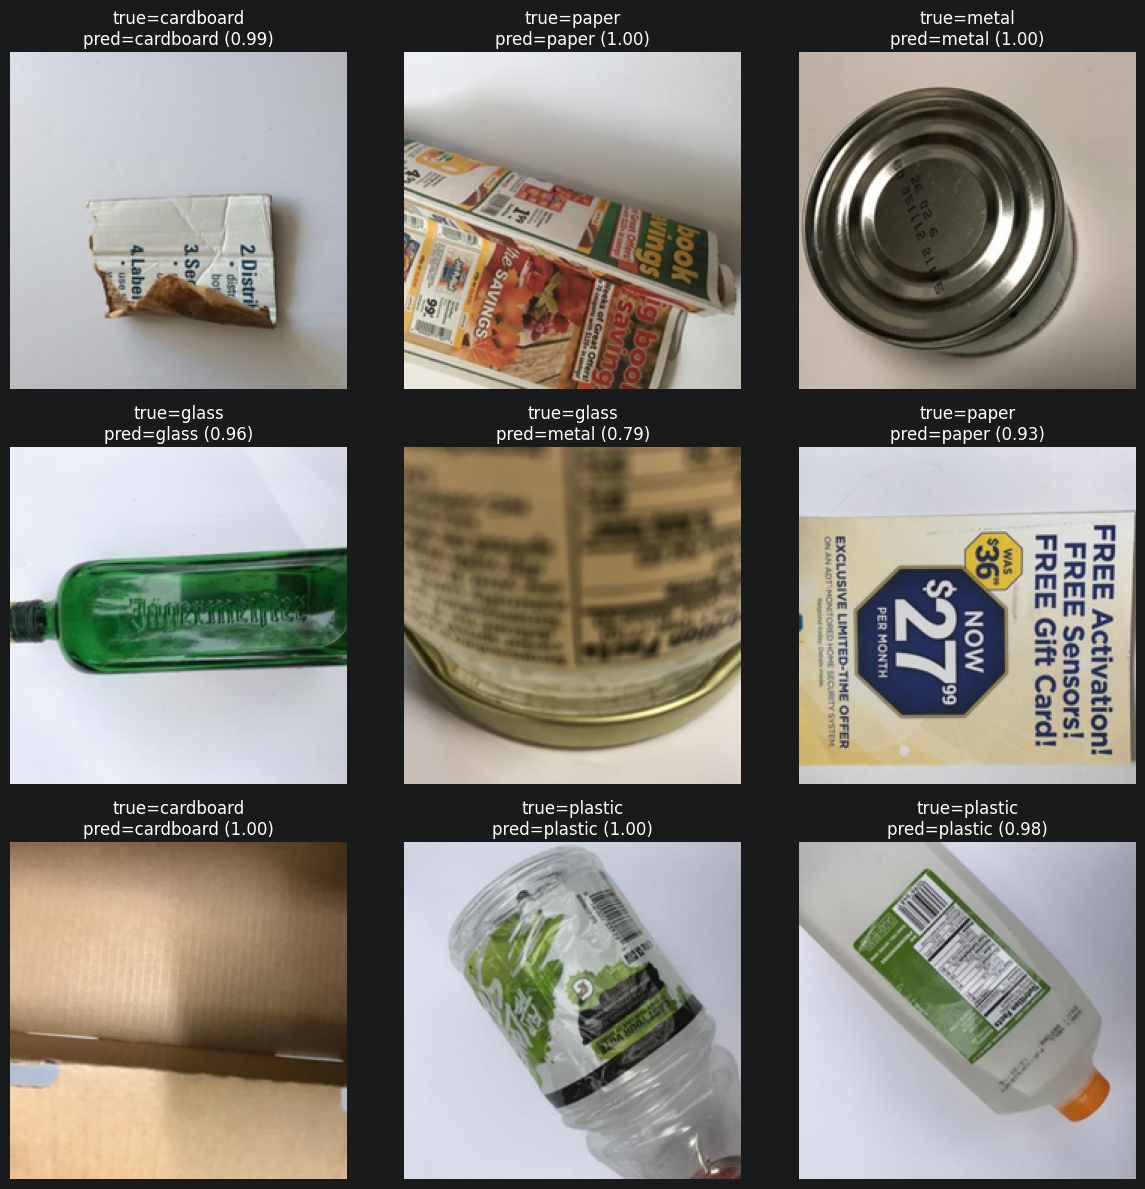

In [41]:
from matplotlib import pyplot as plt

def show_vit_predictions(
        dataset: tf.data.Dataset
        , model: tf.keras.Model
        , id2label: Dict[int, str]
        , max_images: int = 9
) -> None:

    batch_inputs, batch_labels = next(iter(dataset.take(1)))

    probs = model(batch_inputs, training=False)
    pred_ids = tf.argmax(probs, axis=-1)

    images = tf.transpose(batch_inputs["pixel_values"], perm=[0, 2, 3, 1])
    images = (images * IMAGE_STD) + IMAGE_MEAN
    images = tf.clip_by_value(images, 0.0, 1.0)

    total_images = min(max_images, images.shape[0])
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for idx in range(total_images):
        axes[idx].imshow(images[idx].numpy())
        true_label = id2label[int(batch_labels[idx].numpy())]
        pred_label = id2label[int(pred_ids[idx].numpy())]
        pred_prob = float(probs[idx, pred_ids[idx]].numpy())
        axes[idx].set_title(
            f"true={true_label}\npred={pred_label} ({pred_prob:.2f})"
        )
        axes[idx].axis("off")

    for idx in range(total_images, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

show_vit_predictions(
    dataset=test_vit_ds,
    model=vit_model,
    id2label=id2label,
)
